In [1]:
from pynq import Overlay
from pynq.lib.video import *
from pynq import Clocks
Clocks.fclk3_mhz
Clocks.fclk3_mhz = 500

# 1. Load the bitstream
overlay = Overlay("/home/xilinx/julia_mandelbrot.bit")

# Access your pixel_generator instance (assuming it's named 'pixel_generator' in your block design)
# If your IP is named something like 'my_pixel_gen_0', you'd use that.
# Check your block design's address map in Vivado to confirm the instance name.
# For demonstration, let's assume it's overlay.pixel_generator_0
# You might need to adjust this based on your Vivado block design.
# A common pattern is overlay.<instance_name>
# Given your comment pixgen.register_map.gp0 = 0x1234, it seems you already have a pixgen object.
# Let's assume it's like this:
pixgen = overlay.pixel_generator_0 # Adjust this line to match your actual IP instance name


In [23]:
import time
# 2. Define your parameters (example values - adjust as needed)
# Ensure these match the Q-format / data types expected by your HDL
# For example, ZOOM might be an integer, but REAL_CENTER/IMAG_CENTER are fixed-point.
# You mentioned FRAC=28, so these are Q28 numbers.
# Example values for Mandelbrot:
def float_to_q4_28(fval):
    qval = int(round(fval * (1 << 28)))
    if qval < 0:
        qval = (1 << 32) + qval
    return qval

max_iter_log = 9
zoom = 1

re_c_q = float_to_q4_28(-1.787762)
im_c_q = float_to_q4_28(0)
re_c_julia_q = float_to_q4_28(-0.37)
im_c_julia_q = float_to_q4_28(0.6) # go to coords: re(-0.37)

print(re_c_q)
print(im_c_q)
print(max_iter_log)


3815068588
0
9


In [2]:
imgen_vdma = overlay.video.axi_vdma_0.readchannel

In [25]:
# 3. Write parameters to the registers
# Assuming regfile[0] is MAX_ITER, regfile[2] is ZOOM, regfile[3] is REAL_CENTER, regfile[4] is IMAG_CENTER
pixgen = overlay.pixel_generator_0 

max_iter = 2 ** max_iter_log
pixgen.register_map.gp0 = max_iter
pixgen.register_map.gp1 = max_iter_log
pixgen.register_map.gp2 = zoom
pixgen.register_map.gp3 = re_c_q   
pixgen.register_map.gp4 = im_c_q
pixgen.register_map.gp5 = 0
pixgen.register_map.gp6 = re_c_julia_q   
pixgen.register_map.gp7 = im_c_julia_q

print(f"Registers written: MAX_ITER={pixgen.register_map.gp0}, ZOOM={pixgen.register_map.gp2}, REAL_CENTER={pixgen.register_map.gp3}, IMAG_CENTER={pixgen.register_map.gp4}")

Registers written: MAX_ITER=0x200, ZOOM=0x1, REAL_CENTER=0xe36553ac, IMAG_CENTER=0x0


In [3]:
# 4. Initialize and start VDMA read channel
import time

videoMode = common.VideoMode(960, 720, 24) # Assuming 24-bit output (RGB888)
imgen_vdma.mode = videoMode
imgen_vdma.start()

time.sleep(0.5)

In [27]:
frame = imgen_vdma.readframe()


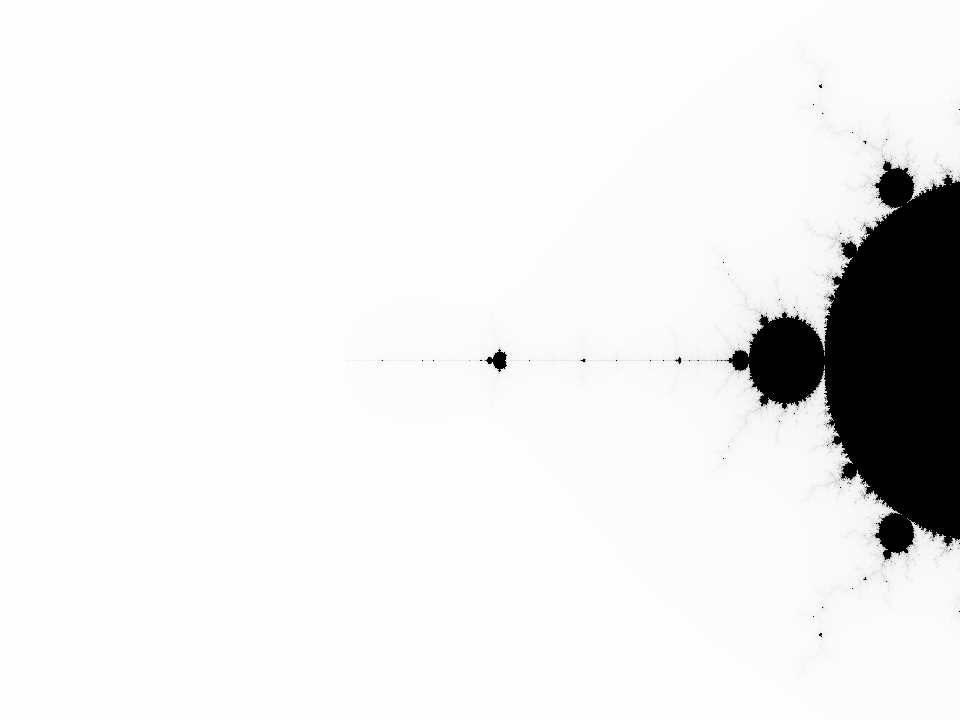

In [28]:
# 7. Process and display the image
import PIL.Image

image = PIL.Image.fromarray(frame)
image # Display the image in Jupyter


In [14]:
import PIL.Image
import time

def get_frame():
    max_attempts = 3
    
    for attempt in range(max_attempts):
        try:
            # Try to read frame
            frame = imgen_vdma.readframe()
            
            if frame is not None:
#                 print(f"frame captured successfully (attempt {attempt+1})")
                return frame
            else:
                print(f"no frame returned (attempt {attempt+1})")
                
        except Exception as e:
            print(f"frame read error (attempt {attempt+1}): {e}")
        
        # Recovery between attempts
        if attempt < max_attempts - 1:
            print("recovery attempt")
            try:
                imgen_vdma.stop()
                time.sleep(0.1)
                imgen_vdma.start()
                time.sleep(0.1)
            except:
                pass
    
    print("all frame read attempts failed")
    return None

# Use it:
frame = get_frame_safe()

if frame is not None:
    import PIL.Image
    image = PIL.Image.fromarray(frame)
    display(image)
    del frame 
else:
    print("no frame to display")


KeyboardInterrupt



In [13]:
del frame


KeyboardInterrupt



In [7]:
def get_frame_safe():
    """Minimal, fast version"""
    try:
        return imgen_vdma.readframe()
    except:
        return None

In [10]:
imgen_vdma.stop()

In [16]:
from pynq import PL
PL.reset()

In [32]:
# FOR loop for testing
import PIL.Image
import time

for i in range (0,5):
    max_iter = 2 ** max_iter_log
    pixgen.register_map.gp0 = max_iter
    pixgen.register_map.gp1 = max_iter_log
    pixgen.register_map.gp2 = i
    pixgen.register_map.gp3 = re_c_q   
    pixgen.register_map.gp4 = im_c_q
    
    get_frame_safe()
    image # Display the image in Jupyter

frame captured successfully (attempt 1)



KeyboardInterrupt



In [ ]:
# Cell for receiving UI parameters - CORRECTED
import asyncio
import websockets
import json
import numpy as np
import PIL
import time

# def get_frame_safe():
#     """Minimal, fast version"""
#     try:
#         return imgen_vdma.readframe()
#     except:
#         return None
pixgen = overlay.pixel_generator_0   

async def send_frame_to_laptop(frame):
    try:
        async with websockets.connect("ws://192.168.137.1:8002") as websocket:
            frame_bytes = frame.tobytes()
            await websocket.send(frame_bytes)
#             print("✅ Frame sent to laptop for processing")
    except Exception as e:
        print(f"❌ Error sending frame: {e}")

async def handle_ui_parameters(websocket, path):
    try:
        async for message in websocket:
            try:
                params = json.loads(message)
                print(params)
                
                
                
                # Update FPGA registers with new parameters
                def float_to_q4_28(fval):
                    qval = int(round(fval * (1 << 28)))
                    if qval < 0:
                        qval = (1 << 32) + qval
                    return qval

                re_c_q = float_to_q4_28(params.get('re_c', -0.5))
                im_c_q = float_to_q4_28(params.get('im_c', 0.0))

                max_iter_log = int(params.get('max_iter', 8))
                max_iter = 2 ** max_iter_log
                zoom = int(params.get('zoom', 1))
                cond = int(params.get('is_julia', 0))
                
                
#                 =============

                

                if cond == 0:  # Mandelbrot mode
                    pixgen.register_map.gp0 = max_iter
                    pixgen.register_map.gp1 = max_iter_log
                    pixgen.register_map.gp2 = zoom         
                    pixgen.register_map.gp3 = re_c_q   
                    pixgen.register_map.gp4 = im_c_q
                    pixgen.register_map.gp5 = 0  # Julia mode flag (0 = Mandelbrot)

                else:  # Julia mode
                    pixgen.register_map.gp0 = max_iter
                    pixgen.register_map.gp1 = max_iter_log
                    pixgen.register_map.gp2 = zoom
                    pixgen.register_map.gp3 = re_c_q   # Still need center for Julia
                    pixgen.register_map.gp4 = im_c_q
                    pixgen.register_map.gp5 = 1  # Julia mode flag (1 = Julia)
                    pixgen.register_map.gp6 = float_to_q4_28(params.get('julia_re', 0.0))
                    pixgen.register_map.gp7 = float_to_q4_28(params.get('julia_im', 0.0))

#                 stale_frame = get_frame_safe()
                
                await asyncio.sleep(0.45)
                
                frame = imgen_vdma.readframe()
                
                await send_frame_to_laptop(frame)
                
                frame = None


            
#                 print(f"   MAX_ITER_LOG: {pixgen.register_map.gp1}")
#                 print(f"   ZOOM: {pixgen.register_map.gp2}")
#                 print(f"   RE_C: {pixgen.register_map.gp3}")
#                 print(f"   IM_C: {pixgen.register_map.gp4}")
                
#                 print("processing frame")
                
                # Read new frame with updated parameters
#                 print("frame updated")
                
                
            except json.JSONDecodeError as e:
                print(f"❌ JSON decode error: {e}")
            except Exception as e:
                print(f"❌ Parameter processing error: {e}")
                
    except websockets.exceptions.ConnectionClosed:
        print("UI disconnected")
    except Exception as e:
        print(f"Connection error: {e}")

# Start parameter server
async def start_param_server():
    print("🚀 Starting FPGA parameter server on 0.0.0.0:8080")
    async with websockets.serve(handle_ui_parameters, "0.0.0.0", 8080):
        print("✅ FPGA parameter server running")
        await asyncio.Future()
# Run this once to start parameter server
task = asyncio.create_task(start_param_server())
print("✅ Server task created and running in background")
print(f"Task: {task}")

✅ Server task created and running in background
Task: <Task pending name='Task-221' coro=<start_param_server() running at /tmp/ipykernel_882/2310710151.py:97>>
🚀 Starting FPGA parameter server on 0.0.0.0:8080
{'re_c': -0.5, 'im_c': 0, 'zoom': 0, 'max_iter': 8}
{'re_c': -0.5, 'im_c': 0, 'zoom': 0, 'max_iter': 8}
{'re_c': -0.5, 'im_c': 0, 'zoom': 1, 'max_iter': 8}
{'re_c': -0.5, 'im_c': 0, 'zoom': 2, 'max_iter': 8}
{'re_c': -0.5, 'im_c': 0, 'zoom': 1, 'max_iter': 8}
{'re_c': -0.5, 'im_c': 0, 'zoom': 0, 'max_iter': 8}
{'re_c': -0.5, 'im_c': 0, 'zoom': 1, 'max_iter': 8}
{'re_c': -0.5, 'im_c': 0, 'zoom': 2, 'max_iter': 8}


In [ ]:
# Cell for clearing VDMA buffer and resetting state
import time

def clear_all_buffers():
    """Aggressively clear all VDMA buffers and reset state"""
    print("🧹 Clearing all VDMA buffers...")
    
    try:
        # Method 1: Read out all buffered frames
        cleared_count = 0
        for i in range(10):  # Try to clear up to 10 frames
            try:
                frame = imgen_vdma.readframe()
                if frame is not None:
                    cleared_count += 1
                    print(f"   Cleared frame {cleared_count}")
                else:
                    break
            except:
                break
            time.sleep(0.01)  # Small delay between reads
        
        print(f"✅ Cleared {cleared_count} buffered frames")
        
        # Method 2: Reset VDMA if possible
        try:
            # If your VDMA has a reset method
            imgen_vdma.reset()
            print("✅ VDMA reset successful")
        except:
            print("ℹ️  VDMA reset not available")
        
        # Method 3: Reset pixel generator if possible
        try:
            pixgen = overlay.pixel_generator_0
            # Try to reset or reinitialize
            if hasattr(pixgen, 'reset'):
                pixgen.reset()
                print("✅ Pixel generator reset")
            elif hasattr(pixgen.register_map, 'reset'):
                pixgen.register_map.reset = 1
                time.sleep(0.01)
                pixgen.register_map.reset = 0
                print("✅ Pixel generator reset via register")
        except:
            print("ℹ️  Pixel generator reset not available")
            
        print("🎯 Buffer clearing complete!")
        return True
        
    except Exception as e:
        print(f"❌ Error during buffer clearing: {e}")
        return False

def set_default_parameters():
    """Set known good default parameters"""
    print("🎛️  Setting default parameters...")
    
    try:
        def float_to_q4_28(fval):
            qval = int(round(fval * (1 << 28)))
            if qval < 0:
                qval = (1 << 32) + qval
            return qval
        
        pixgen = overlay.pixel_generator_0
        
        # Default Mandelbrot parameters
        default_re_c = -0.5
        default_im_c = 0.0
        default_max_iter_log = 8
        default_max_iter = 2 ** default_max_iter_log
        default_zoom = 1
        
        # Convert and set
        re_c_q = float_to_q4_28(default_re_c)
        im_c_q = float_to_q4_28(default_im_c)
        
        pixgen.register_map.gp0 = default_max_iter
        pixgen.register_map.gp1 = default_max_iter_log
        pixgen.register_map.gp2 = default_zoom
        pixgen.register_map.gp3 = re_c_q
        pixgen.register_map.gp4 = im_c_q
        
        print(f"✅ Default parameters set:")
        print(f"   Center: ({default_re_c}, {default_im_c}i)")
        print(f"   Max iterations: {default_max_iter}")
        print(f"   Zoom: {default_zoom}")
        
        return True
        
    except Exception as e:
        print(f"❌ Error setting default parameters: {e}")
        return False

# Execute the clearing process
print("🚀 Starting buffer and state clearing...")
buffer_cleared = clear_all_buffers()
params_set = set_default_parameters()

if buffer_cleared and params_set:
    print("✅ System ready! You can now run the parameter server.")
    
    # Wait a moment for everything to settle
    time.sleep(0.5)
    
    # Test frame read
    try:
        test_frame = imgen_vdma.readframe()
        if test_frame is not None:
            print(f"✅ Test frame read successful - Shape: {test_frame.shape}")
        else:
            print("⚠️  Test frame read returned None")
    except Exception as e:
        print(f"⚠️  Test frame read failed: {e}")
else:
    print("❌ Setup incomplete. Check errors above.")